# 🧠 Classification: AI vs Real + Category

## Two problems, two model tiers

| Problem | Input | Output | Classes |
|---------|-------|--------|---------|
| **Task 1** | Image | AI or Real | 2 |
| **Task 2** | Image | animals / city / food / nature / people | 5 |

## Champion-Challenger setup (required by rubric)

| Model | What it is | Why it's the challenger/champion |
|-------|-----------|----------------------------------|
| **Baseline** | Frozen EfficientNet-B0, retrain only final layer | Simple, fast, strong starting point |
| **Champion** | Full fine-tuned EfficientNet-B0, shared backbone, two output heads (multi-task) | Learns both tasks simultaneously, more parameters adapted to your data |

## What is multi-task learning?
Instead of training two separate models, we train **one model with a shared backbone**.
The backbone (EfficientNet) learns visual features that are useful for BOTH tasks.
Then two separate 'heads' (small classifiers) each make their own prediction.

```
Image → EfficientNet Backbone → shared features
                                      ├── Head 1 → AI or Real  (binary)
                                      └── Head 2 → category    (5-class)
```

**Why is this better?** The model can't overfit to one task — the backbone must learn
features general enough to serve both. This acts as a regularizer and often improves
both tasks compared to training them independently.

## 1. Setup & Imports

In [1]:
import os, random, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)

import kagglehub

# ── Reproducibility ──
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Constants ──
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_WORKERS = 0       # must be 0 in Jupyter on Mac/Windows
EPOCHS_BASE = 5       # baseline: fewer epochs, backbone is frozen
EPOCHS_FULL = 15      # champion: more epochs, full fine-tuning
LR_BASE     = 1e-3    # higher LR for baseline (only training one layer)
LR_FULL     = 1e-4    # lower LR for fine-tuning (careful not to destroy pretrained weights)

# ── Labels ──
BINARY_LABELS   = {'Real': 0, 'AI': 1}
CATEGORY_LABELS = {'animals': 0, 'city': 1, 'food': 2, 'nature': 3, 'people': 4}
IDX_TO_BINARY   = {v: k for k, v in BINARY_LABELS.items()}
IDX_TO_CATEGORY = {v: k for k, v in CATEGORY_LABELS.items()}

# ── Device ──
if torch.cuda.is_available():          DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available(): DEVICE = torch.device('mps')
else:                                   DEVICE = torch.device('cpu')
print(f'✅ Imports done | Device: {DEVICE}')

✅ Imports done | Device: mps


## 2. Load Data & Rebuild Splits

We load the saved CSVs from the preprocessing notebook.
If those don't exist yet, we rebuild everything from scratch here.

In [2]:
from sklearn.model_selection import train_test_split

def build_dataframe(dataset_path):
    IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
    LABEL_MAP = {'real_dataset': 'Real', 'Ai_generated_dataset': 'AI'}
    records = []
    for label_folder in sorted(Path(dataset_path).iterdir()):
        if not label_folder.is_dir(): continue
        label = LABEL_MAP.get(label_folder.name, label_folder.name)
        for cat_folder in sorted(label_folder.iterdir()):
            if not cat_folder.is_dir(): continue
            for img_path in cat_folder.iterdir():
                if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                    records.append({
                        'path'        : str(img_path),
                        'label'       : label,
                        'label_idx'   : BINARY_LABELS[label],
                        'category'    : cat_folder.name,
                        'category_idx': CATEGORY_LABELS[cat_folder.name],
                    })
    return pd.DataFrame(records)

# Try loading saved splits first
try:
    df_train = pd.read_csv('train_split.csv')
    df_val   = pd.read_csv('val_split.csv')
    df_test  = pd.read_csv('test_split.csv')
    # add category_idx if missing from old CSV
    for df in [df_train, df_val, df_test]:
        if 'category_idx' not in df.columns:
            df['category_idx'] = df['category'].map(CATEGORY_LABELS)
    print('✅ Loaded splits from CSV')
except FileNotFoundError:
    print('CSV splits not found — rebuilding from scratch...')
    raw_path = kagglehub.dataset_download('rhythmghai/ai-vs-real-images-dataset')
    df = build_dataframe(raw_path)
    df['strat_key'] = df['label'] + '_' + df['category']
    df_tv, df_test  = train_test_split(df, test_size=0.15, stratify=df['strat_key'], random_state=SEED)
    df_train, df_val = train_test_split(df_tv, test_size=0.15/0.85, stratify=df_tv['strat_key'], random_state=SEED)
    df_train = df_train.reset_index(drop=True)
    df_val   = df_val.reset_index(drop=True)
    df_test  = df_test.reset_index(drop=True)

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
df_train.head(3)

CSV splits not found — rebuilding from scratch...
Train: 695 | Val: 150 | Test: 150


,path,label,label_idx,category,category_idx,strat_key
0,/Users/bestek/.cache/kagglehub/datasets/rhythm...,Real,0,animals,0,Real_animals
1,/Users/bestek/.cache/kagglehub/datasets/rhythm...,AI,1,city,1,AI_city
2,/Users/bestek/.cache/kagglehub/datasets/rhythm...,AI,1,city,1,AI_city


## 3. Dataset Class — Dual Label

This dataset returns **two labels per image** instead of one:
- `label_idx`    → 0 (Real) or 1 (AI)
- `category_idx` → 0-4 (animals/city/food/nature/people)

The baseline model will only use one of these at a time.
The multi-task champion uses both simultaneously.

In [3]:
class AIvsRealDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        binary_label   = torch.tensor(int(row['label_idx']),    dtype=torch.long)
        category_label = torch.tensor(int(row['category_idx']), dtype=torch.long)
        return image, binary_label, category_label

    def get_binary_labels(self):
        return self.df['label_idx'].astype(int).tolist()

# ── Transforms ──
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = AIvsRealDataset(df_train, train_transforms)
val_ds   = AIvsRealDataset(df_val,   val_test_transforms)
test_ds  = AIvsRealDataset(df_test,  val_test_transforms)

# ── Weighted sampler for binary imbalance ──
bin_labels    = train_ds.get_binary_labels()
class_counts  = Counter(bin_labels)
sample_weights = torch.tensor([1.0/class_counts[l] for l in bin_labels])
sampler = WeightedRandomSampler(sample_weights, len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=NUM_WORKERS)

# Quick shape check
imgs, blabels, clabels = next(iter(train_loader))
print(f'✅ Dataset ready')
print(f'Image batch : {imgs.shape}')          # [32, 3, 224, 224]
print(f'Binary labels : {blabels[:8].tolist()}')
print(f'Category labels: {clabels[:8].tolist()}')

✅ Dataset ready
Image batch : torch.Size([32, 3, 224, 224])
Binary labels : [0, 0, 0, 1, 0, 1, 1, 1]
Category labels: [3, 3, 2, 4, 3, 1, 0, 1]


## 4. Helper Functions (Shared)

These functions are used by both models — defines them once.

In [4]:
def train_one_epoch(model, loader, optimizer, criterion_fn, device, task='binary'):
    """
    Runs one full pass through the training data.
    task = 'binary'    → uses binary labels only
    task = 'category'  → uses category labels only
    task = 'multitask' → uses both, model returns two outputs
    """
    model.train()  # puts model in training mode (enables dropout, batchnorm updates)
    total_loss, correct, total = 0.0, 0, 0

    for imgs, b_labels, c_labels in loader:
        imgs     = imgs.to(device)
        b_labels = b_labels.to(device)
        c_labels = c_labels.to(device)

        optimizer.zero_grad()   # clear gradients from previous step

        if task == 'multitask':
            out_b, out_c  = model(imgs)
            loss          = criterion_fn(out_b, out_c, b_labels, c_labels)
            preds         = out_b.argmax(dim=1)
            correct      += (preds == b_labels).sum().item()
        elif task == 'binary':
            out           = model(imgs)
            loss          = criterion_fn(out, b_labels)
            preds         = out.argmax(dim=1)
            correct      += (preds == b_labels).sum().item()
        else:  # category
            out           = model(imgs)
            loss          = criterion_fn(out, c_labels)
            preds         = out.argmax(dim=1)
            correct      += (preds == c_labels).sum().item()

        loss.backward()     # compute gradients
        optimizer.step()    # update weights

        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()   # tells PyTorch: don't track gradients here (saves memory)
def evaluate(model, loader, criterion_fn, device, task='binary'):
    """
    Evaluates model on val or test set.
    Returns loss, accuracy, and raw predictions + true labels for metric computation.
    """
    model.eval()   # disables dropout, freezes batchnorm
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_true = [], [], []

    for imgs, b_labels, c_labels in loader:
        imgs     = imgs.to(device)
        b_labels = b_labels.to(device)
        c_labels = c_labels.to(device)

        if task == 'multitask':
            out_b, out_c = model(imgs)
            loss         = criterion_fn(out_b, out_c, b_labels, c_labels)
            probs        = torch.softmax(out_b, dim=1)[:, 1]
            preds        = out_b.argmax(dim=1)
            true         = b_labels
        elif task == 'binary':
            out   = model(imgs)
            loss  = criterion_fn(out, b_labels)
            probs = torch.softmax(out, dim=1)[:, 1]
            preds = out.argmax(dim=1)
            true  = b_labels
        else:
            out   = model(imgs)
            loss  = criterion_fn(out, c_labels)
            probs = torch.softmax(out, dim=1)
            preds = out.argmax(dim=1)
            true  = c_labels

        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == true).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().tolist() if task != 'category' else probs.cpu().tolist())
        all_true.extend(true.cpu().tolist())

    return total_loss/total, correct/total, all_preds, all_probs, all_true


def plot_training_curves(history, title):
    """Plots loss and accuracy curves for train and val."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    epochs = range(1, len(history['train_loss'])+1)

    axes[0].plot(epochs, history['train_loss'], 'o-', label='Train', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   's-', label='Val',   color='coral')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history['train_acc'], 'o-', label='Train', color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   's-', label='Val',   color='coral')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    axes[1].legend(); axes[1].grid(True)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', bbox_inches='tight', dpi=150)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """Plots a labeled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(5, len(class_names)*1.5), max(4, len(class_names)*1.3)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_cm.png', bbox_inches='tight', dpi=150)
    plt.show()


def print_metrics(y_true, y_pred, y_probs, class_names, task='binary'):
    """Prints full classification report + AUC."""
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    try:
        if task == 'binary':
            auc = roc_auc_score(y_true, y_probs)
        else:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        print(f'AUC-ROC: {auc:.4f}')
    except Exception:
        pass

print('✅ Helper functions defined')

✅ Helper functions defined


---
# MODEL 1 — BASELINE
## Frozen EfficientNet-B0, Single Task at a Time

### What EfficientNet-B0 is:
EfficientNet is a family of CNNs designed to be efficient — it achieves high accuracy
with fewer parameters than alternatives like ResNet.
The 'B0' is the smallest variant — perfect for fine-tuning on small datasets.

It was pretrained on **ImageNet** — 1.2 million images, 1000 classes.
This means its backbone already knows how to detect edges, textures, shapes, objects.
We just need to teach it to use those features for our specific task.

### Baseline strategy — freeze and replace:
```
EfficientNet-B0
├── Backbone (FROZEN — weights don't change)
│   All the convolutional layers that detect features
└── Classifier head (REPLACED + TRAINED)
    Original: Linear(1280 → 1000)  ← 1000 ImageNet classes
    Ours:     Linear(1280 → 2)     ← binary: AI vs Real
              OR Linear(1280 → 5)  ← 5 categories
```
**Why freeze?** We trust the pretrained features. Training a frozen backbone is faster
and avoids destroying learned representations with a small dataset.

In [5]:
def build_baseline(num_classes):
    """
    Frozen EfficientNet-B0 with a new classification head.
    num_classes: 2 for binary, 5 for category.
    """
    # Load pretrained weights (downloads ~20MB first time)
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Step 1: Freeze ALL backbone parameters
    # requires_grad=False means: don't compute gradients for this parameter
    # → the optimizer won't update it → the weights stay frozen
    for param in model.parameters():
        param.requires_grad = False

    # Step 2: Replace the final classifier head
    # EfficientNet-B0's classifier is at model.classifier
    # It produces 1280 features → we replace with our own output size
    in_features = model.classifier[1].in_features  # = 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),                          # dropout: randomly zero out 20% of neurons during training
        nn.Linear(in_features, num_classes)          # our actual classifier
    )
    # The new layers have requires_grad=True by default → they WILL be trained

    return model.to(DEVICE)


# Count trainable vs frozen parameters — good sanity check
def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'  Trainable params : {trainable:,}  ({trainable/total*100:.1f}% of total)')
    print(f'  Frozen params    : {total-trainable:,}')
    print(f'  Total params     : {total:,}')

print('=== Baseline Binary (2 classes) ===')
baseline_binary = build_baseline(num_classes=2)
count_params(baseline_binary)

print('\n=== Baseline Category (5 classes) ===')
baseline_category = build_baseline(num_classes=5)
count_params(baseline_category)

=== Baseline Binary (2 classes) ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/bestek/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 43.5MB/s]


  Trainable params : 2,562  (0.1% of total)
  Frozen params    : 4,007,548
  Total params     : 4,010,110

=== Baseline Category (5 classes) ===
  Trainable params : 6,405  (0.2% of total)
  Frozen params    : 4,007,548
  Total params     : 4,013,953


## 4b. Train Baseline — Binary (AI vs Real)

Training Baseline Binary for 5 epochs...
(Only the final layer is being updated — fast!)
-------------------------------------------------------
Epoch 1/5 | Train Loss: 0.4806 Acc: 0.594 | Val Loss: 0.4880 Acc: 0.607 | 23.6s
Epoch 2/5 | Train Loss: 0.2989 Acc: 0.839 | Val Loss: 0.3483 Acc: 0.820 | 15.3s
Epoch 3/5 | Train Loss: 0.2449 Acc: 0.840 | Val Loss: 0.2809 Acc: 0.887 | 15.6s
Epoch 4/5 | Train Loss: 0.2031 Acc: 0.917 | Val Loss: 0.2432 Acc: 0.913 | 16.6s
Epoch 5/5 | Train Loss: 0.1951 Acc: 0.895 | Val Loss: 0.2296 Acc: 0.900 | 16.1s


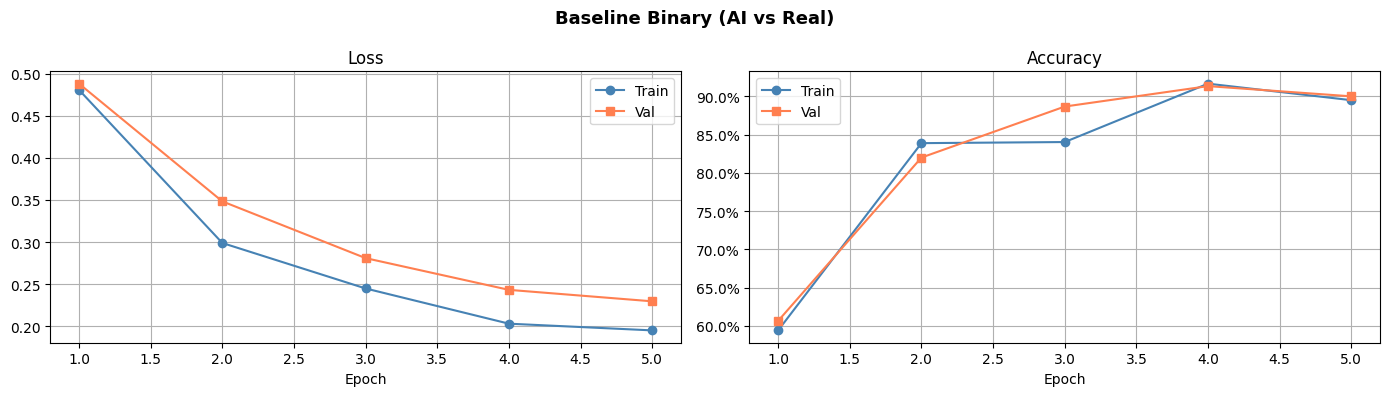

In [6]:
# Loss function for binary classification
# CrossEntropyLoss with class weights to handle the 3:1 imbalance
n_real = (df_train['label'] == 'Real').sum()
n_ai   = (df_train['label'] == 'AI').sum()
n_total = len(df_train)
binary_weights = torch.tensor([
    n_total / (2 * n_real),   # weight for Real (class 0)
    n_total / (2 * n_ai),     # weight for AI   (class 1)
], dtype=torch.float).to(DEVICE)

criterion_binary   = nn.CrossEntropyLoss(weight=binary_weights)
criterion_category = nn.CrossEntropyLoss()   # categories are balanced — no weights needed

# Adam optimizer — only passing parameters that require gradients
# If we passed all params, we'd try to optimize frozen layers (no-op but wasteful)
optimizer_base_bin = optim.Adam(
    filter(lambda p: p.requires_grad, baseline_binary.parameters()),
    lr=LR_BASE
)

print(f'Training Baseline Binary for {EPOCHS_BASE} epochs...')
print('(Only the final layer is being updated — fast!)')
print('-' * 55)

history_base_bin = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(EPOCHS_BASE):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(
        baseline_binary, train_loader, optimizer_base_bin,
        criterion_binary, DEVICE, task='binary'
    )
    vl_loss, vl_acc, _, _, _ = evaluate(
        baseline_binary, val_loader, criterion_binary, DEVICE, task='binary'
    )
    history_base_bin['train_loss'].append(tr_loss)
    history_base_bin['val_loss'].append(vl_loss)
    history_base_bin['train_acc'].append(tr_acc)
    history_base_bin['val_acc'].append(vl_acc)
    print(f'Epoch {epoch+1}/{EPOCHS_BASE} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f} | '
          f'{time.time()-t0:.1f}s')

plot_training_curves(history_base_bin, 'Baseline Binary (AI vs Real)')

## 4c. Train Baseline — Category (5 classes)

Training Baseline Category for 5 epochs...
-------------------------------------------------------
Epoch 1/5 | Train Loss: 1.2679 Acc: 0.580 | Val Loss: 0.8576 Acc: 0.880 | 16.1s
Epoch 2/5 | Train Loss: 0.6985 Acc: 0.898 | Val Loss: 0.5867 Acc: 0.893 | 16.4s
Epoch 3/5 | Train Loss: 0.5180 Acc: 0.911 | Val Loss: 0.4800 Acc: 0.913 | 15.5s
Epoch 4/5 | Train Loss: 0.4011 Acc: 0.918 | Val Loss: 0.3898 Acc: 0.933 | 15.7s
Epoch 5/5 | Train Loss: 0.3389 Acc: 0.950 | Val Loss: 0.3431 Acc: 0.953 | 16.1s


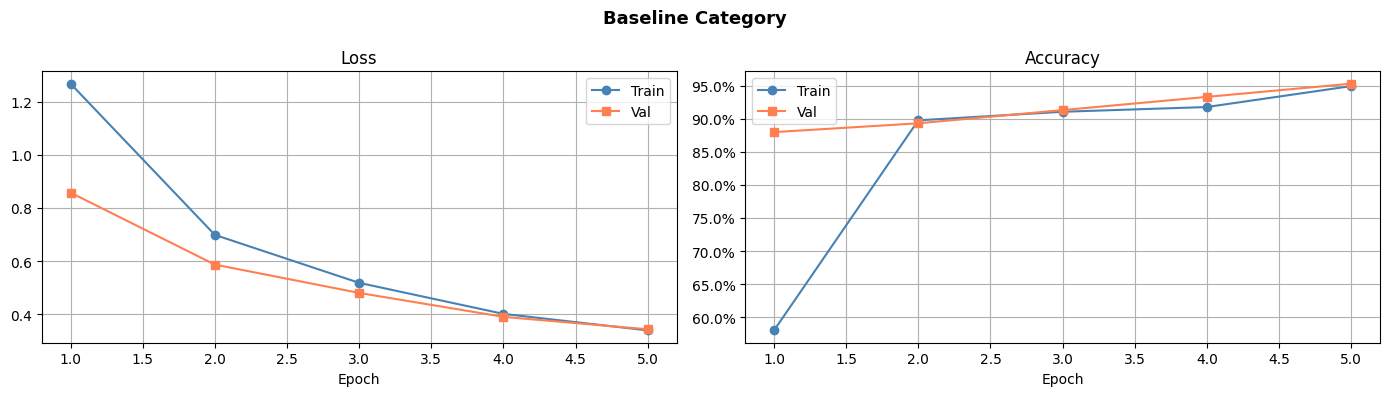

In [7]:
optimizer_base_cat = optim.Adam(
    filter(lambda p: p.requires_grad, baseline_category.parameters()),
    lr=LR_BASE
)

print(f'Training Baseline Category for {EPOCHS_BASE} epochs...')
print('-' * 55)

history_base_cat = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(EPOCHS_BASE):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(
        baseline_category, train_loader, optimizer_base_cat,
        criterion_category, DEVICE, task='category'
    )
    vl_loss, vl_acc, _, _, _ = evaluate(
        baseline_category, val_loader, criterion_category, DEVICE, task='category'
    )
    history_base_cat['train_loss'].append(tr_loss)
    history_base_cat['val_loss'].append(vl_loss)
    history_base_cat['train_acc'].append(tr_acc)
    history_base_cat['val_acc'].append(vl_acc)
    print(f'Epoch {epoch+1}/{EPOCHS_BASE} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f} | '
          f'{time.time()-t0:.1f}s')

plot_training_curves(history_base_cat, 'Baseline Category')

---
# MODEL 2 — CHAMPION
## Full Fine-Tuned EfficientNet-B0 with Dual Heads (Multi-Task Learning)

### Architecture:
```
Image (224×224×3)
    ↓
EfficientNet-B0 Backbone  [FULLY TRAINED — all layers update]
    ↓
Shared feature vector (1280-dim)
    ├── Head 1: Dropout → Linear(1280→256) → ReLU → Linear(256→2)   → AI/Real
    └── Head 2: Dropout → Linear(1280→256) → ReLU → Linear(256→5)   → Category
```

### Multi-task loss:
Both heads contribute to the total loss:
```
total_loss = α × loss_binary + (1-α) × loss_category
```
We use α=0.6 — slightly more weight on binary since that's our primary task.
The gradients from BOTH tasks flow back through the shared backbone.
This is what makes the backbone learn richer, more general features.

In [9]:
class MultiTaskEfficientNet(nn.Module):
    """
    EfficientNet-B0 backbone with two classification heads:
    - head_binary:   2 outputs  (AI vs Real)
    - head_category: 5 outputs  (animals/city/food/nature/people)
    """
    def __init__(self):
        super().__init__()

        # Load pretrained backbone
        effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Keep everything EXCEPT the final classifier
        # model.features = all the convolutional layers
        # model.avgpool  = global average pooling (collapses spatial dims to 1x1)
        self.backbone = nn.Sequential(
            effnet.features,
            effnet.avgpool,
            nn.Flatten()   # [batch, 1280, 1, 1] → [batch, 1280]
        )

        in_features = 1280  # EfficientNet-B0 backbone output size

        # Head 1: Binary classification (AI vs Real)
        self.head_binary = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

        # Head 2: Category classification (5 classes)
        self.head_category = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, 5)
        )

    def forward(self, x):
        features = self.backbone(x)          # shared feature extraction
        out_binary   = self.head_binary(features)
        out_category = self.head_category(features)
        return out_binary, out_category      # return BOTH outputs


champion = MultiTaskEfficientNet().to(DEVICE)

print('=== Champion: Multi-Task EfficientNet ===')
count_params(champion)

# Multi-task loss function
# alpha controls how much each task contributes to the total loss
ALPHA = 0.6   # 60% weight on binary (primary task), 40% on category

def multitask_criterion(out_b, out_c, labels_b, labels_c):
    loss_b = criterion_binary(out_b, labels_b)
    loss_c = criterion_category(out_c, labels_c)
    return ALPHA * loss_b + (1 - ALPHA) * loss_c

# Lower LR for fine-tuning — we're updating pretrained weights carefully
# Using weight_decay (L2 regularization) to prevent overfitting on small dataset
optimizer_champion = optim.Adam(champion.parameters(), lr=LR_FULL, weight_decay=1e-4)

# Learning rate scheduler: reduce LR when val loss stops improving
# This lets us start with LR=1e-4 and automatically decrease it if we plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_champion, mode='min', patience=3, factor=0.5, verbose=False
)

print(f'\nLoss weight α={ALPHA} → binary loss weighted {ALPHA:.0%}, category loss {1-ALPHA:.0%}')

=== Champion: Multi-Task EfficientNet ===
  Trainable params : 4,665,219  (100.0% of total)
  Frozen params    : 0
  Total params     : 4,665,219


TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

## 5b. Train Champion

In [ ]:
print(f'Training Champion (Multi-Task) for {EPOCHS_FULL} epochs...')
print('Both heads train simultaneously. Backbone is fully updated.')
print('-' * 60)

history_champion = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_loss = float('inf')
best_weights  = None

for epoch in range(EPOCHS_FULL):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(
        champion, train_loader, optimizer_champion,
        multitask_criterion, DEVICE, task='multitask'
    )
    vl_loss, vl_acc, _, _, _ = evaluate(
        champion, val_loader, multitask_criterion, DEVICE, task='multitask'
    )

    history_champion['train_loss'].append(tr_loss)
    history_champion['val_loss'].append(vl_loss)
    history_champion['train_acc'].append(tr_acc)
    history_champion['val_acc'].append(vl_acc)

    # Save best model weights (based on val loss)
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = {k: v.clone() for k, v in champion.state_dict().items()}
        print(f'  ✅ New best model saved (val_loss={vl_loss:.4f})')

    scheduler.step(vl_loss)   # adjust LR if plateau

    print(f'Epoch {epoch+1:2d}/{EPOCHS_FULL} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f} | '
          f'{time.time()-t0:.1f}s')

# Restore best weights before evaluation
champion.load_state_dict(best_weights)
print(f'\n✅ Restored best weights (val_loss={best_val_loss:.4f})')
plot_training_curves(history_champion, 'Champion Multi-Task')

---
# Final Evaluation on TEST SET

⚠️ **This is the honest evaluation.** We only look at the test set once.
The test set was never used for training or for any decisions during development.

We evaluate all models and compare them side by side.

## 6a. Task 1 — Binary (AI vs Real): Baseline vs Champion

In [ ]:
print('=' * 60)
print('TASK 1: BINARY CLASSIFICATION — AI vs Real')
print('=' * 60)

# ── Baseline on test set ──
print('\n--- BASELINE (Frozen EfficientNet) ---')
_, base_bin_acc, base_bin_preds, base_bin_probs, base_bin_true = evaluate(
    baseline_binary, test_loader, criterion_binary, DEVICE, task='binary'
)
print_metrics(base_bin_true, base_bin_preds, base_bin_probs,
              class_names=['Real', 'AI'], task='binary')

# ── Champion on test set ──
print('\n--- CHAMPION (Multi-Task Fine-Tuned) ---')
_, champ_bin_acc, champ_bin_preds, champ_bin_probs, champ_bin_true = evaluate(
    champion, test_loader, multitask_criterion, DEVICE, task='multitask'
)
print_metrics(champ_bin_true, champ_bin_preds, champ_bin_probs,
              class_names=['Real', 'AI'], task='binary')

In [ ]:
# ── Confusion matrices side by side ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
binary_names = ['Real', 'AI']

for ax, preds, true, title in [
    (axes[0], base_bin_preds, base_bin_true, 'Baseline Binary'),
    (axes[1], champ_bin_preds, champ_bin_true, 'Champion Binary'),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=binary_names, yticklabels=binary_names,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Binary Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

# ── ROC Curve comparison ──
fig, ax = plt.subplots(figsize=(7, 6))
for probs, true, label, color in [
    (base_bin_probs, base_bin_true, 'Baseline', 'steelblue'),
    (champ_bin_probs, champ_bin_true, 'Champion', 'coral'),
]:
    fpr, tpr, _ = roc_curve(true, probs)
    auc = roc_auc_score(true, probs)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1],'--', color='gray', label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Binary Classification', fontweight='bold')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('binary_roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()

## 6b. Task 2 — Category (5 classes): Baseline vs Champion

In [ ]:
print('=' * 60)
print('TASK 2: MULTI-CLASS — Category (5 classes)')
print('=' * 60)
category_names = ['animals', 'city', 'food', 'nature', 'people']

print('\n--- BASELINE (Frozen EfficientNet) ---')
_, base_cat_acc, base_cat_preds, base_cat_probs, base_cat_true = evaluate(
    baseline_category, test_loader, criterion_category, DEVICE, task='category'
)
print_metrics(base_cat_true, base_cat_preds, base_cat_probs,
              class_names=category_names, task='category')

print('\n--- CHAMPION (Multi-Task Fine-Tuned — Category Head) ---')
# For champion category evaluation, run a dedicated pass
@torch.no_grad()
def evaluate_category_head(model, loader, device):
    model.eval()
    all_preds, all_probs, all_true = [], [], []
    for imgs, _, c_labels in loader:
        imgs = imgs.to(device)
        _, out_c = model(imgs)
        probs = torch.softmax(out_c, dim=1)
        preds = out_c.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
        all_true.extend(c_labels.tolist())
    return all_preds, all_probs, all_true

champ_cat_preds, champ_cat_probs, champ_cat_true = evaluate_category_head(champion, test_loader, DEVICE)
print_metrics(champ_cat_true, champ_cat_preds, champ_cat_probs,
              class_names=category_names, task='category')

In [ ]:
# ── Category confusion matrices ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, true, title in [
    (axes[0], base_cat_preds, base_cat_true, 'Baseline Category'),
    (axes[1], champ_cat_preds, champ_cat_true, 'Champion Category'),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=category_names, yticklabels=category_names,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Confusion Matrices — Category Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('category_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Head-to-Head Comparison Table

In [ ]:
def safe_auc_binary(true, probs):
    try: return roc_auc_score(true, probs)
    except: return float('nan')

def safe_auc_multi(true, probs):
    try: return roc_auc_score(true, probs, multi_class='ovr', average='macro')
    except: return float('nan')

results = {
    'Task': [
        'Binary (AI vs Real)', 'Binary (AI vs Real)',
        'Category (5-class)',  'Category (5-class)',
    ],
    'Model': ['Baseline', 'Champion', 'Baseline', 'Champion'],
    'Accuracy': [
        accuracy_score(base_bin_true, base_bin_preds),
        accuracy_score(champ_bin_true, champ_bin_preds),
        accuracy_score(base_cat_true, base_cat_preds),
        accuracy_score(champ_cat_true, champ_cat_preds),
    ],
    'F1 (macro)': [
        f1_score(base_bin_true, base_bin_preds, average='macro'),
        f1_score(champ_bin_true, champ_bin_preds, average='macro'),
        f1_score(base_cat_true, base_cat_preds, average='macro'),
        f1_score(champ_cat_true, champ_cat_preds, average='macro'),
    ],
    'AUC-ROC': [
        safe_auc_binary(base_bin_true, base_bin_probs),
        safe_auc_binary(champ_bin_true, champ_bin_probs),
        safe_auc_multi(base_cat_true, base_cat_probs),
        safe_auc_multi(champ_cat_true, champ_cat_probs),
    ],
}

df_results = pd.DataFrame(results)
df_results[['Accuracy','F1 (macro)','AUC-ROC']] = df_results[['Accuracy','F1 (macro)','AUC-ROC']].round(4)

print('\n' + '='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)
print(df_results.to_string(index=False))

# Visual bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Accuracy', 'F1 (macro)', 'AUC-ROC']
colors  = {'Baseline': 'steelblue', 'Champion': 'coral'}

for ax, metric in zip(axes, metrics):
    for task in df_results['Task'].unique():
        subset = df_results[df_results['Task'] == task]
        x = [f"{task}\n{row['Model']}" for _, row in subset.iterrows()]
        y = subset[metric].values
        c = [colors[m] for m in subset['Model']]
        bars = ax.bar(x, y, color=c, edgecolor='black', linewidth=0.6)
        for bar, val in zip(bars, y):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.4)

# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
fig.legend(handles=handles, loc='upper right', fontsize=10)

plt.suptitle('Model Comparison: Baseline vs Champion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Error Analysis — What is the model getting wrong?

In [ ]:
# Find the most confidently wrong predictions from the champion binary model
# These are the hardest cases — worth looking at visually

@torch.no_grad()
def get_all_predictions_with_paths(model, dataset, device):
    model.eval()
    results = []
    for idx in range(len(dataset)):
        img_tensor, b_label, c_label = dataset[idx]
        img_batch = img_tensor.unsqueeze(0).to(device)  # add batch dim
        out_b, _ = model(img_batch)
        prob  = torch.softmax(out_b, dim=1)[0, 1].item()  # prob of being AI
        pred  = out_b.argmax(dim=1).item()
        results.append({
            'path'      : dataset.df.iloc[idx]['path'],
            'true_label': b_label.item(),
            'pred_label': pred,
            'ai_prob'   : prob,
            'correct'   : pred == b_label.item(),
            'category'  : dataset.df.iloc[idx]['category'],
        })
    return pd.DataFrame(results)

print('Collecting predictions on test set (this takes a moment)...')
df_preds = get_all_predictions_with_paths(champion, test_ds, DEVICE)

# Most confidently wrong predictions
wrong = df_preds[~df_preds['correct']].copy()
# Sort: Real images predicted as AI with high confidence, and vice versa
wrong['confidence'] = wrong.apply(
    lambda r: r['ai_prob'] if r['pred_label']==1 else 1-r['ai_prob'], axis=1
)
top_wrong = wrong.sort_values('confidence', ascending=False).head(8)

print(f'\nTotal test images : {len(df_preds)}')
print(f'Correct           : {df_preds["correct"].sum()}')
print(f'Wrong             : {(~df_preds["correct"]).sum()}')
print(f'\nTop 8 most confidently wrong predictions:')

def unnormalize(t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t * std + mean).clamp(0,1)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top_wrong.iterrows()):
    img = Image.open(row['path']).convert('RGB')
    img_t = val_test_transforms(img)
    img_display = unnormalize(img_t).permute(1,2,0).numpy()
    ax.imshow(img_display)
    true_name = IDX_TO_BINARY[row['true_label']]
    pred_name = IDX_TO_BINARY[row['pred_label']]
    ax.set_title(
        f'True: {true_name} | Pred: {pred_name}\n'
        f'Confidence: {row["confidence"]:.2%} | Cat: {row["category"]}',
        fontsize=9, color='red'
    )
    ax.axis('off')

plt.suptitle('Most Confidently Wrong Predictions (Champion Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Error rate by category — which scene type is hardest to classify?
error_by_cat = df_preds.groupby('category').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
)
error_by_cat['error_rate'] = 1 - error_by_cat['correct'] / error_by_cat['total']
error_by_cat = error_by_cat.sort_values('error_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(error_by_cat.index, error_by_cat['error_rate'],
              color='salmon', edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, error_by_cat['error_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.1%}', ha='center', fontweight='bold')
ax.set_title('Binary Classification Error Rate by Category\n(Champion Model)',
             fontweight='bold')
ax.set_ylabel('Error Rate')
ax.set_ylim(0, 0.6)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('error_by_category.png', bbox_inches='tight', dpi=150)
plt.show()

print(error_by_cat[['total','correct','error_rate']].to_string())

## 9. Save Models

In [ ]:
torch.save(baseline_binary.state_dict(),   'baseline_binary.pth')
torch.save(baseline_category.state_dict(), 'baseline_category.pth')
torch.save(champion.state_dict(),          'champion_multitask.pth')
df_results.to_csv('classification_results.csv', index=False)

print('✅ Saved:')
print('  baseline_binary.pth      — frozen EfficientNet, AI vs Real')
print('  baseline_category.pth    — frozen EfficientNet, 5 categories')
print('  champion_multitask.pth   — fine-tuned multi-task model')
print('  classification_results.csv')

print('\n' + '='*60)
print('CLASSIFICATION NOTEBOOK COMPLETE')
print('='*60)
print('Next: Style Transfer notebook (CycleGAN vs Neural Style Transfer)')